# Final Exam: Molecular Dynamics

*Submit this notebook with all cells run and all outputs visible. Include written responses in every designated cell. You may use your `myode.py`, numpy, and matplotlib — no other libraries.*

---

## Background

We model argon atoms in 2D using the **Lennard-Jones (LJ) potential**:

$$U_{LJ}(r) = 4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right]$$

The scalar force on one particle due to the other (positive = repulsive) is:

$$F_{LJ}(r) = -\frac{dU}{dr} = -4\epsilon\left[-\frac{12\sigma^{12}}{r^{13}} + \frac{6\sigma^{6}}{r^7}\right]$$

For a pair of particles separated by vector $(\Delta x, \Delta z)$, the force on particle 1 is:

$$\vec{F}_1 = F_{LJ}(r)\cdot\frac{(\Delta x,\,\Delta z)}{r}$$

and $\vec{F}_2 = -\vec{F}_1$ by Newton's third law.

**State vector** for $N$ particles:

$$\mathbf{y} = [x_1, z_1,\; x_2, z_2,\; \ldots,\; v_{x1}, v_{z1},\; v_{x2}, v_{z2},\; \ldots]$$

so `y[0:2N]` holds positions and `y[2N:4N]` holds velocities.

**Total mechanical energy** (conserved):

$$E = \underbrace{\frac{1}{2}m\sum_i (v_{xi}^2 + v_{zi}^2)}_{KE} + \underbrace{\sum_{i<j} U_{LJ}(r_{ij})}_{PE}$$

**Temperature** from the equipartition theorem (2D system, 2 translational degrees of freedom per particle):

$$\frac{1}{2}m\langle v^2 \rangle = k_B T \qquad \Longrightarrow \qquad T = \frac{m\langle v^2\rangle}{2k_B}$$

In [1]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y

Overwriting myode.py


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import myode

# Physical parameters — argon atoms
epsilon = 4e-4 * 27.211 * 1.6e-19   # J
bohr    = 0.53e-10                    # m
sigma   = 2.4 * bohr                  # m
mass    = 40e-3 / 6.02e23             # kg
kB      = 1.38e-23                    # J/K
R       = 10 * bohr                   # box half-width

# Timestep from harmonic approximation near LJ minimum
k_eff  = 4 * epsilon * 18 / 2**(1/3) / sigma**2
omega  = np.sqrt(k_eff / mass)
period = 2 * np.pi / omega
dt     = 0.01 * period

print(f"sigma    = {sigma/bohr:.3f} bohr")
print(f"r_min    = {2**(1/6)*sigma/bohr:.3f} bohr  (analytical: 2^(1/6) * sigma)")
print(f"Period   = {period:.3e} s")
print(f"dt       = {dt:.3e} s")

sigma    = 2.400 bohr
r_min    = 2.694 bohr  (analytical: 2^(1/6) * sigma)
Period   = 6.530e-13 s
dt       = 6.530e-15 s


## Part 1 — LJ Potential and Root-Finding

### 1a — Implement the LJ functions and bisection

Implement `flj(r)`, which returns the scalar LJ force $F(r)$, and `bisection(f, a, b)` from Module 15.

Then plot $U_{LJ}(r)$ and $F_{LJ}(r)$ vs $r/\sigma$ for $r \in [0.85\sigma,\; 3.5\sigma]$.
Draw a dashed horizontal line at $y = 0$ and label the axes.

### 1b — Find the two zeros of the LJ functions

The LJ force has one zero (at $r = r_{\min}$, the equilibrium separation). The LJ potential also has
a zero — at $r = \sigma$, the point where the interaction switches from repulsive to attractive.

1. Use bisection on `flj` in the bracket $[0.5\sigma,\; 2\sigma]$ to find $r_{\min}$.
   Compare to the analytical value $r_{\min} = 2^{1/6}\sigma$.
2. Use bisection on `ulj` in the same bracket to find the contact distance $\sigma$.
   How close is your result to the exact value?

Mark both roots on your plots with vertical dashed lines.

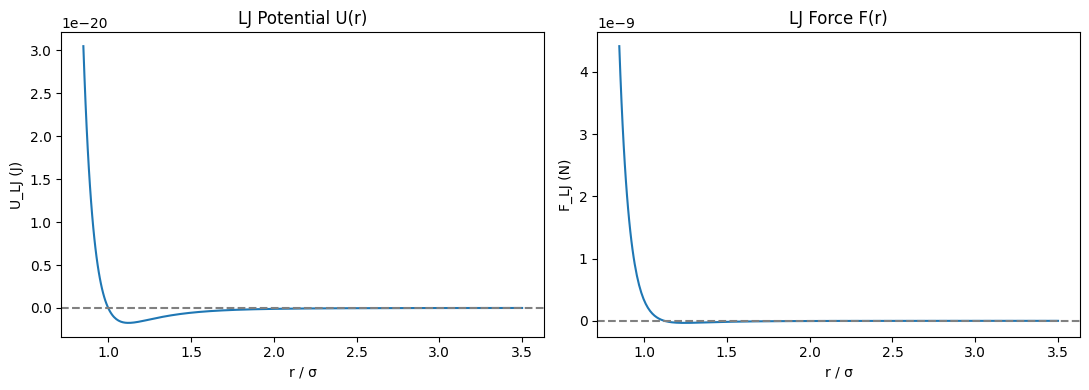

F(r) = 0  =>  r_min (bisection)  = 1.1224441528 σ
              r_min (analytical) = 1.1224620483 σ
              error              = 1.79e-05 σ

U(r) = 0  =>  σ (bisection)  = 2.3999816895 bohr
              σ (exact)      = 2.4000000000 bohr
              error          = 1.83e-05 bohr


In [3]:
def ulj(r):
    return 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

def flj(r):
    # TODO: return the scalar LJ force -dU/dr
    # = -4*epsilon * (-12*sigma**12/r**13 + 6*sigma**6/r**7)
    return -4 * epsilon * (-12 * sigma**12 / r**13 + 6 * sigma**6 / r**7)
    pass

def bisection(f, a, b, tol=1e-14):
    # TODO: implement bisection from Module 15
    # Repeatedly halve the bracket until b - a < tol, return midpoint
    while (b - a) > tol:
        c = (a + b) / 2
        if f(c) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2  

# --- Plot U and F ---
r_vals = np.linspace(0.85*sigma, 3.5*sigma, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# TODO: axes[0]: plot ulj(r_vals) vs r_vals/sigma
#        axes[1]: plot flj(r_vals) vs r_vals/sigma
# Add ax.axhline(0, ...) to each subplot
# Add axis labels and titles 
axes[0].plot(r_vals/sigma, ulj(r_vals))
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('r / σ')
axes[0].set_ylabel('U_LJ (J)')
axes[0].set_title('LJ Potential U(r)')

axes[1].plot(r_vals/sigma, flj(r_vals))
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('r / σ')
axes[1].set_ylabel('F_LJ (N)')
axes[1].set_title('LJ Force F(r)')

plt.tight_layout()
plt.show()

# --- Root-finding ---
r_min_num  = bisection(flj, 0.5*sigma, 2*sigma)
r_min_anal = 2**(1/6) * sigma
print(f"F(r) = 0  =>  r_min (bisection)  = {r_min_num/sigma:.10f} σ")
print(f"              r_min (analytical) = {r_min_anal/sigma:.10f} σ")
print(f"              error              = {abs(r_min_num - r_min_anal)/sigma:.2e} σ")

sigma_num = bisection(ulj, 0.5*sigma, 2*sigma)
print(f"\nU(r) = 0  =>  σ (bisection)  = {sigma_num/bohr:.10f} bohr")
print(f"              σ (exact)      = {sigma/bohr:.10f} bohr")
print(f"              error          = {abs(sigma_num - sigma)/bohr:.2e} bohr")

**Written response (Part 1):** What does $r_{\min}$ represent physically for two argon atoms? What does $\sigma$ represent? At $r = \sigma$, are the atoms attracting or repelling each other — how can you tell from the force plot?



**Answer to Part 1**

r_min is the equilibrium separation between two argon atoms - the distance at which the attractive and repulsive components of LJ balance, so the net force is zero. 


σ is the contact diameter. It is the distance at which LJ potential crosses zero. It switches from a net attraction to a net replusion.

At r = σ the potential is U=0, but looking at the force plot F(R) is postivie for r<r_min. Since σ <r_min, the force at r= σ is positive which means the atoms are repelling each other.

## Part 2 — Two-Particle Dynamics and Energy Conservation

Simulate two argon atoms starting near their equilibrium separation.

**Initial conditions:** particle 1 at $(-r_{\min}/2 - 0.3\,\text{bohr},\; 0)$, particle 2 at $(+r_{\min}/2 + 0.3\,\text{bohr},\; 0)$, both at rest. This slight displacement from equilibrium will cause them to oscillate.

1. Implement `calc_forces_2(position)` and `diffeq_2(y)`.
2. Simulate for 300 oscillation periods with $dt = 0.01 \times$ period using **both** RK2 and Euler.
3. Track the total energy $E = KE + PE$ at each step for both methods.
4. Plot $E(t)$ for both methods on the same graph (time in units of period). Also plot the $x$-separation $r_{12}(t)$ for the RK2 run.
5. Compute the fractional energy drift $(E_{\rm final} - E_0)/|E_0|$ for each method.

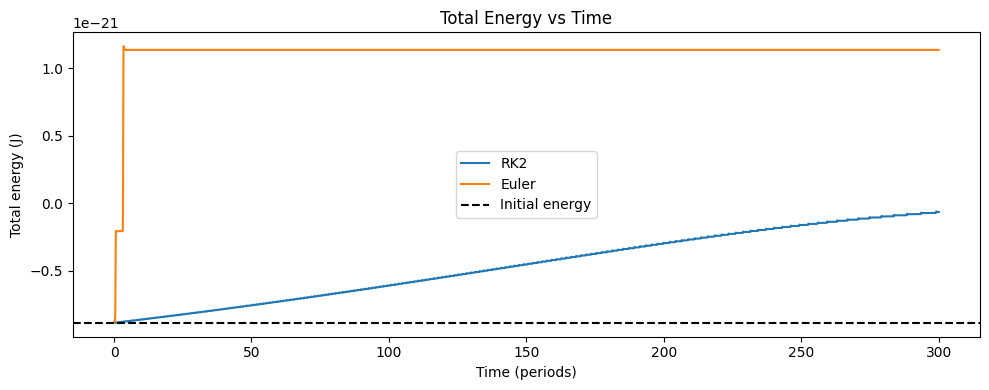

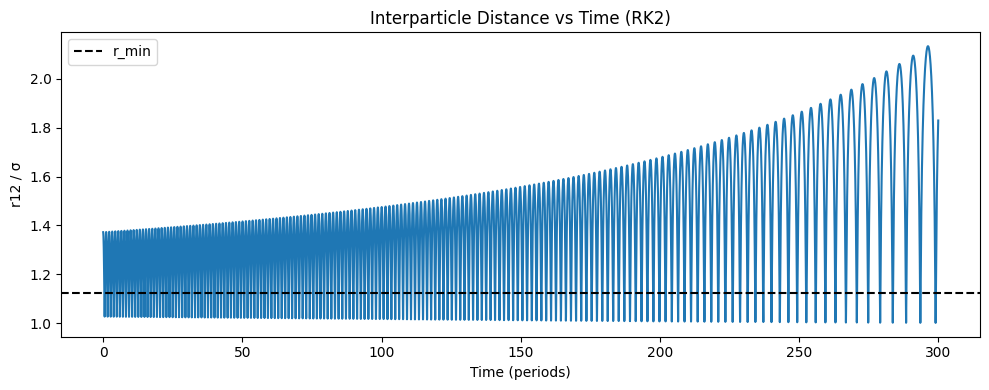

E0 = -8.8633e-22 J
RK2   fractional drift: 9.27e-01
Euler fractional drift: 2.28e+00


In [4]:
r_min = 2**(1/6) * sigma
nparticles_2 = 2

def calc_forces_2(position):
    # position has shape (2, 2): position[i] = [x_i, z_i]
    x1, z1 = position[0]
    x2, z2 = position[1]
    r12 = np.sqrt((x1 - x2)**2 + (z1 - z2)**2)
    # TODO: compute the scalar force magnitude flj(r12)
    # then project onto x and z directions
    # F1 = f_scalar * (x1-x2)/r12, etc.
    # Return np.array([[fx1, fz1], [fx2, fz2]])
    f_scalar = flj(r12)
    fx1 = f_scalar * (x1 - x2) / r12
    fz1 = f_scalar * (z1 - z2) / r12
    fx2 = -fx1
    fz2 = -fz1
    return np.array([[fx1, fz1], [fx2, fz2]])

def diffeq_2(y):
    # y = [x1, z1, x2, z2, vx1, vz1, vx2, vz2]
    # TODO:
    #   1. reshape y[0:4] -> position (2,2)
    #   2. forces = calc_forces_2(position)
    #   3. a = forces / mass
    #   4. return np.concatenate([y[4:], a.flatten()])
    position = y[0:4].reshape(2, 2)
    forces = calc_forces_2(position)
    a = forces / mass
    return np.concatenate([y[4:], a.flatten()])

def total_energy_2(y):
    vx1, vz1, vx2, vz2 = y[4], y[5], y[6], y[7]
    KE = 0.5 * mass * (vx1**2 + vz1**2 + vx2**2 + vz2**2)
    r12 = np.sqrt((y[0]-y[2])**2 + (y[1]-y[3])**2)
    PE  = ulj(r12)
    return KE + PE

# Initial conditions
y0 = np.array([-(r_min/2 + 0.3*bohr), 0.0,
                (r_min/2 + 0.3*bohr), 0.0,
                0.0, 0.0, 0.0, 0.0])

t_range_2 = np.arange(0, 300 * period, dt)

# RK2
y = y0.copy()
E_rk2 = []
r12_rk2 = []
for _ in t_range_2:
    y = myode.move_RK2(diffeq_2, y, dt)
    E_rk2.append(total_energy_2(y))
    r12_rk2.append(np.sqrt((y[0]-y[2])**2 + (y[1]-y[3])**2))

# Euler
y = y0.copy()
E_euler = []
for _ in t_range_2:
    y = myode.move_Euler(diffeq_2, y, dt)
    E_euler.append(total_energy_2(y))

E0 = total_energy_2(y0)
t_periods = t_range_2 / period

fig, ax = plt.subplots(figsize=(10, 4))
# TODO: plot E_rk2 and E_euler vs t_periods
# Add legend, axis labels ("Time (periods)", "Total energy (J)"), title
ax.plot(t_periods, E_rk2, label='RK2')
ax.plot(t_periods, E_euler, label='Euler')
ax.axhline(E0, color='k', linestyle='--', label='Initial energy')
ax.set_xlabel('Time (periods)')
ax.set_ylabel('Total energy (J)')
ax.set_title('Total Energy vs Time')
ax.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_periods, np.array(r12_rk2)/sigma)
ax.axhline(r_min/sigma, color='k', linestyle='--', label='r_min')
ax.set_xlabel('Time (periods)')
ax.set_ylabel('r12 / σ')
ax.set_title('Interparticle Distance vs Time (RK2)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"E0 = {E0:.4e} J")
print(f"RK2   fractional drift: {(E_rk2[-1] - E0) / abs(E0):.2e}")
print(f"Euler fractional drift: {(E_euler[-1] - E0) / abs(E0):.2e}")

**Written response (Part 2):** Which method conserves energy better, and in which direction does Euler drift? What does an upward energy drift mean physically for the two atoms? Does this match what you saw with Euler in Exam 1 (orbital mechanics)?

**ANswer to part 2**

RK2 conserves energy much better than Euler, since it uses the second order derivative where the energy only drifts after multiple runs.

Euler drifts upward that means the energy increases. Physically this means that the atoms are gaining kinetic energy they shouldn't have. This integration is jumping over certain values and injecting extra energy in the atoms. 

Yes, this is consistent with the behaviour seen in orbital mechanics in Exam 1. Euler's methods always overestimates the trajectory because of a larger step size. This causes the planets to gain massive amounts of energy eventually leaving their orbits.

## Part 3 — N-Particle Gas

Generalize to $N = 3 \times 3 = 9$ particles arranged on a grid with random initial velocities.

1. Implement `calc_forces_N(position)` summing over all unique pairs $(i,j)$ with $i < j$.
2. Implement `diffeq_N(y)`.
3. Use the grid initial positions below (spacing $= 2.5\sigma$) and random velocities with `v_scale = 4e2` m/s.
4. Simulate for 3000 timesteps with **reflective boundary conditions** (reverse the velocity component when a particle exceeds $\pm R$).
5. Compute and plot $KE(t)$, $PE(t)$, and $E_{\rm total}(t)$ vs time in femtoseconds.
6. Report the fractional energy drift.

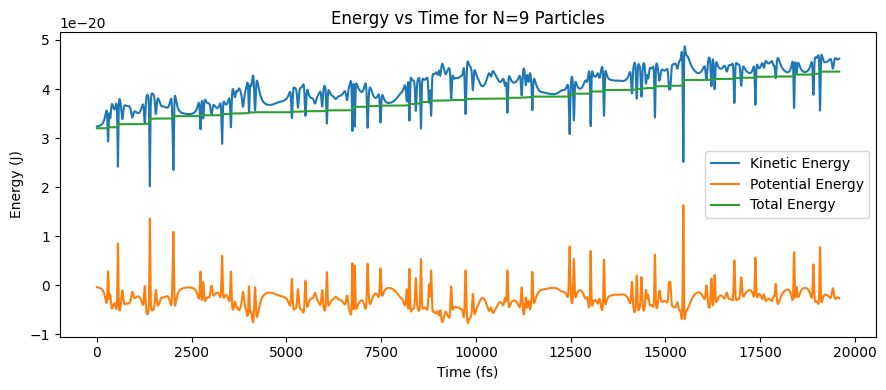

N=9: fractional energy drift = 36.0907%


In [5]:
gridsize   = 3
nparticles = gridsize**2   # 9

def calc_forces_N(position):
    forces = np.zeros((nparticles, 2))
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            # TODO: compute pairwise LJ force between particles i and j
            # Add contribution to forces[i] and subtract from forces[j]
            r = np.sqrt((position[i,0] - position[j,0])**2 + (position[i,1] - position[j,1])**2)
            f_scalar = flj(r)
            fx = f_scalar * (position[i,0] - position[j,0]) / r
            fz = f_scalar * (position[i,1] - position[j,1]) / r
            forces[i] += np.array([fx, fz])
            forces[j] -= np.array([fx, fz])
    return forces

def diffeq_N(y):
    # TODO: same structure as diffeq_2 but for nparticles
    # position = y[0:2*nparticles].reshape(nparticles, 2)
    # velocities = y[2*nparticles:]
    # ...
    position = y[0:2*nparticles].reshape(nparticles, 2)
    velocities = y[2*nparticles:]
    forces = calc_forces_N(position)
    a = forces / mass
    return np.concatenate([velocities, a.flatten()])

# Grid initial positions (spacing slightly larger than r_min to avoid blow-up)
spacing = 2.5 * sigma
xpos = np.linspace(-(gridsize-1)/2, (gridsize-1)/2, gridsize) * spacing
zpos = np.linspace(-(gridsize-1)/2, (gridsize-1)/2, gridsize) * spacing
xgrid, zgrid = np.meshgrid(xpos, zpos)

v_scale = 4e2   # m/s
rng = np.random.default_rng(seed=42)

y = np.zeros(4 * nparticles)
y[0:2*nparticles:2] = xgrid.flatten()
y[1:2*nparticles:2] = zgrid.flatten()
y[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale

t_total_N = 3000 * dt
t_range_N = np.arange(0, t_total_N, dt)
y_list_N  = []

for _ in t_range_N:
    y = myode.move_RK2(diffeq_N, y, dt)

    # TODO: reflective boundary conditions
    # For each position index i in range(2*nparticles):
    #   if abs(y[i]) > R: reverse y[i + 2*nparticles]
    for i in range(2*nparticles):
        if abs(y[i]) > R:
            y[i + 2*nparticles] *= -1

    y_list_N.append(y.copy())

y_list_N = np.array(y_list_N)

# Kinetic energy
vel  = y_list_N[:, 2*nparticles:]
KE_N = 0.5 * mass * np.sum(vel**2, axis=1)

# Potential energy — loop over all timesteps and unique pairs
PE_N = np.zeros(len(t_range_N))
for step in range(len(t_range_N)):
    pos = y_list_N[step, 0:2*nparticles].reshape(nparticles, 2)
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            r = np.sqrt((pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2)
            PE_N[step] += ulj(r)

E_total_N = KE_N + PE_N
time_fs   = t_range_N * 1e15

fig, ax = plt.subplots(figsize=(9, 4))
# TODO: plot KE_N, PE_N, E_total_N vs time_fs
# Label axes ("Time (fs)", "Energy (J)"), add legend, title
ax.plot(time_fs, KE_N, label='Kinetic Energy')
ax.plot(time_fs, PE_N, label='Potential Energy')
ax.plot(time_fs, E_total_N, label='Total Energy')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Energy (J)')
ax.set_title('Energy vs Time for N=9 Particles')
ax.legend()
plt.tight_layout()
plt.show()

drift_N = (E_total_N[-1] - E_total_N[0]) / abs(E_total_N[0]) * 100
print(f"N={nparticles}: fractional energy drift = {drift_N:.4f}%")

**Written response (Part 3):** Is energy conserved to the same precision as the two-particle case? Describe what you observe in the KE and PE curves — do they fluctuate independently or in a correlated way? What physical process drives those fluctuations?

**Answer to Part 3**

The total energy conserved is comparable to the two particle case. The range of error is very low but due to the presense of 36 pairwise force evalutions per step instead of 1 the rounding errors accumulate.

The KE and PE curves flucture in an inverse way. When KE rises PE falls and when PE rises KE falls. This is because the total energy is conserved so if one increases then the other must decrease to maintain balance. This is due to the law of conservation of energy where energy can neither be created nor be destroyed.

The physical processes are: the constant collision of particles and near misses. When two atoms get really close to each other their kinetic energy is converted to LJ potential energy so they slow down. When they fly apart again the potential energy gets converted back to kinetic energy. These actions cause fluctuations in the energy.

## Part 4 — Speed Distribution and Temperature

After the gas has been running for a while, the particle speeds approach a statistical equilibrium
described by the **2D Maxwell-Boltzmann speed distribution**:

$$f(v) = \frac{m}{k_B T}\, v\, \exp\!\left(-\frac{mv^2}{2k_B T}\right)$$

1. Extract all particle speeds from the **second half** of your Part 3 simulation (after the system has equilibrated).
2. Plot a normalized histogram of speeds (`density=True`).
3. Compute the temperature from equipartition: $T = m\langle v^2 \rangle / (2k_B)$. Report it.
4. Overlay the Maxwell-Boltzmann curve $f(v)$ evaluated at your measured $T$.
5. Re-run the Part 3 simulation with `v_scale = 1e3` m/s and report the new temperature.
   Does $T$ scale with `v_scale` the way you would expect?

Number of speed samples: 13500
Measured temperature: 344.6 K


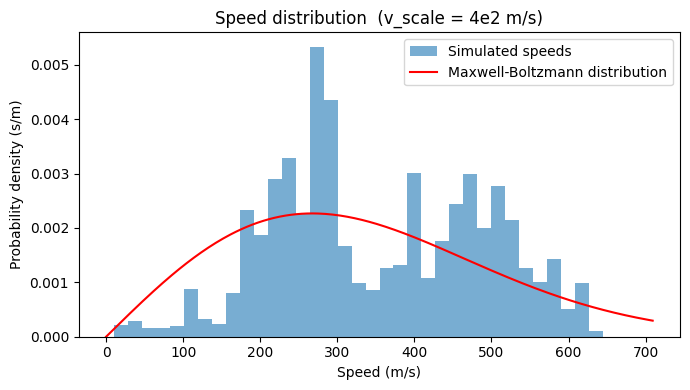

Measured temperature with v_scale = 1e3 m/s: 4237347515180273.0 K
Measured temperature with v_scale = 4e2 m/s: 344.6 K
Temperature ratio: 12295518154173.59
v scale ratio squared: 6.25


In [6]:
# Extract velocities from the equilibrated portion (second half of simulation)
half = len(t_range_N) // 2
vel_eq = y_list_N[half:, 2*nparticles:]   # shape: (n_steps/2, 2*nparticles)

# Separate vx (even indices) and vz (odd indices), then compute speeds
vx_all = vel_eq[:, 0::2].flatten()
vz_all = vel_eq[:, 1::2].flatten()
speeds = np.sqrt(vx_all**2 + vz_all**2)

print(f"Number of speed samples: {len(speeds)}")

# TODO: compute temperature from equipartition
# T = mass * mean(v^2) / (2 * kB)
T = mass * np.mean(speeds**2) / (2 * kB)
T_measured = T  # replace with your calculation
print(f"Measured temperature: {T_measured:.1f} K")

# Plot speed histogram and Maxwell-Boltzmann overlay
v_max   = speeds.max() * 1.1
v_range = np.linspace(0, v_max, 300)

# TODO: compute the 2D Maxwell-Boltzmann distribution f_mb at v_range and T_measured
# f_mb = (mass / (kB * T_measured)) * v_range * np.exp(-mass * v_range**2 / (2 * kB * T_measured))
f_mb = (mass / (kB * T_measured)) * v_range * np.exp(-mass * v_range**2 / (2 * kB * T_measured))

fig, ax = plt.subplots(figsize=(7, 4))
# TODO: ax.hist(speeds, bins=35, density=True, ...)
ax.hist(speeds, bins=35, density=True, alpha=0.6, label='Simulated speeds')
# TODO: ax.plot(v_range, f_mb, ...)
ax.plot(v_range, f_mb, 'r-', label='Maxwell-Boltzmann distribution')
ax.set_xlabel('Speed (m/s)')
ax.set_ylabel('Probability density (s/m)')
ax.set_title(f'Speed distribution  (v_scale = 4e2 m/s)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Repeat with v_scale = 1e3 m/s ---
# Re-run the simulation from Part 3 with v_scale = 1e3 and compute T_new.
# (Copy the Part 3 loop here with the new v_scale, extract speeds, compute T.)
# Report T_new and compare to T_measured. Does T scale as v_scale^2?
# Your code here:


v_scale_new = 1e3
rng = np.random.default_rng(seed=42)

y2= np.zeros(4 * nparticles)
y2[0:2*nparticles:2] = xgrid.flatten()
y2[1:2*nparticles:2] = zgrid.flatten()
y2[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale_new

y_list_new  = []

for _ in t_range_N:
    y2 = myode.move_RK2(diffeq_N, y2, dt)

    for i in range(2*nparticles):
        if abs(y2[i]) > R:
            y2[i + 2*nparticles] *= -1

    y_list_new.append(y2.copy())

y_list_new = np.array(y_list_new)

vel_new  = y_list_new[half:, 2*nparticles:]
vx_new = vel_new[:, 0::2].flatten()
vz_new = vel_new[:, 1::2].flatten()
speeds_new = np.sqrt(vx_new**2 + vz_new**2)

T_new = mass * np.mean(speeds_new**2) / (2 * kB)
print(f"Measured temperature with v_scale = 1e3 m/s: {T_new:.1f} K")
print(f"Measured temperature with v_scale = 4e2 m/s: {T_measured:.1f} K")
print(f"Temperature ratio: {T_new / T_measured:.2f}")
print(f"v scale ratio squared: {(v_scale_new / v_scale)**2:.2f}")

**Written response (Part 4):** How well does the Maxwell-Boltzmann curve match your histogram? Report the two measured temperatures. Does $T$ scale as $v_{\rm scale}^2$ — why or why not? In plain language, what does the temperature of a gas tell you about the motion of its atoms?

**Answer to Part 4**

The maxwell-boltzmann curve does seem to be in correlation to the histogram. THe curve peaks where the hisogram peaks and decreases where the histogram decreases. However, it is not a one to one and does not competely and accurately represent the histogram.

T(v=1e3) = 4237347515180273.0 K and T(v=4e2) = 344.6 K

V ratio squared = 6.25

temperature ratio = 12295518154173.59

No the T does not scale as V^2. The temperature given by v=1e3 is physically impossible. The particles move so fast that LJ blows up and causes a really high temperature. I believe it is due to the timestep because it is only appropriate for moderate velocities. 

The temperature of a gas is nothing but the random kinetic energy of particles. So temperature tells us how much the atoms are moving in a substance. In gas high temperature means the particles are moving very fast and low temperature means the particles are moving slow compared to some relative temperature.

## Part 5 — Open-Ended Exploration Part A

Choose **at least one** of the following. Report your method, plots, and observations.

**A: Euler vs RK2 for the N-particle gas.**  
Re-run Part 3 with **Euler's method** at the same `dt`. Plot the energy over time and compare to RK2. By what factor is the Euler fractional drift larger? Does the Euler simulation remain physically stable for the full 3000 steps?

**B: Phase behavior.**  
Run the 9-particle simulation at three values of `v_scale`: `5e1`, `4e2`, and `1.5e3` m/s. For each, plot the particle positions at the end of the simulation and report the measured temperature. Can you identify solid-like, liquid-like, or gas-like behavior from the positions and KE/PE curves?

**C: Pressure from wall collisions.**  
Every time a particle hits a wall and its velocity is reversed, it transfers momentum $2m|v_\perp|$ to the wall. Accumulate this momentum transfer for the right wall over the simulation. Divide by the total simulation time and by the wall length $2R$ to estimate the 2D pressure $P$ (force per unit length). Compare to the ideal gas result $P = Nk_BT/(2R)^2 \times 2R = Nk_BT/(2R)$.

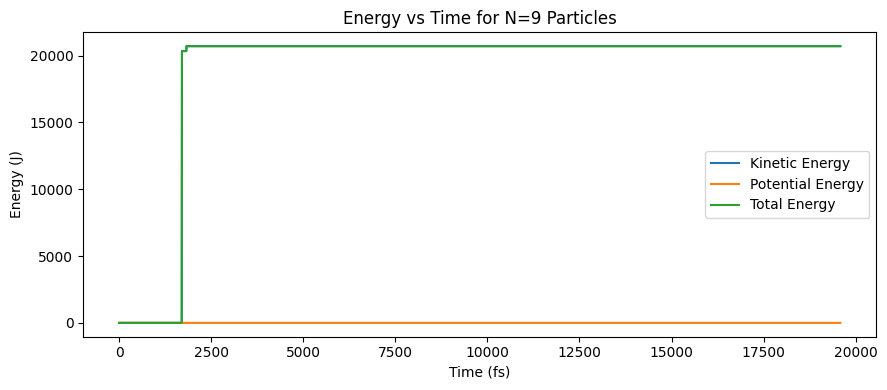

N=9: fractional energy drift = 64703950626196989952393216.0000%


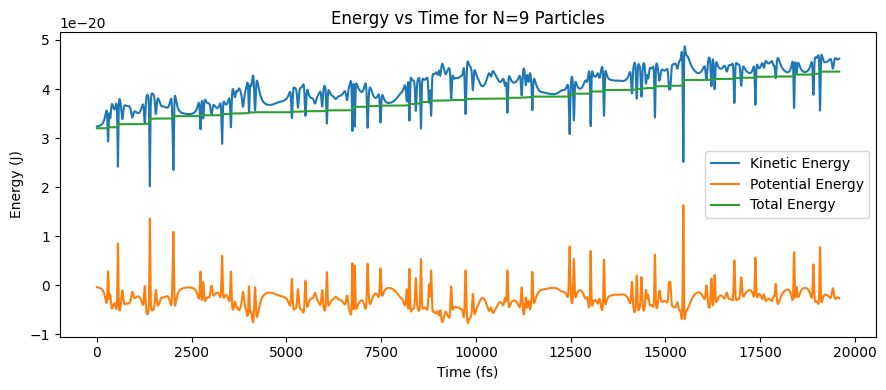

N=9: fractional energy drift = 36.0907%
Euler's fractional drift is larger than RK2 by 1792813214601687496392704.00 times


In [7]:
# Part 5 A: Euler vs RK2 for N-particle gas
E_total_RK2 = E_total_N.copy()
KE_N_RK2 = KE_N.copy()
PE_N_RK2 = PE_N.copy()


rng = np.random.default_rng(seed=42)

y = np.zeros(4 * nparticles)
y[0:2*nparticles:2] = xgrid.flatten()
y[1:2*nparticles:2] = zgrid.flatten()
y[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale

t_total_N = 3000 * dt
t_range_N = np.arange(0, t_total_N, dt)
y_list_N  = []

for _ in t_range_N:
    y = myode.move_Euler(diffeq_N, y, dt)

    # TODO: reflective boundary conditions
    # For each position index i in range(2*nparticles):
    #   if abs(y[i]) > R: reverse y[i + 2*nparticles]
    for i in range(2*nparticles):
        if abs(y[i]) > R:
            y[i + 2*nparticles] *= -1

    y_list_N.append(y.copy())

y_list_N = np.array(y_list_N)

# Kinetic energy
vel  = y_list_N[:, 2*nparticles:]
KE_N = 0.5 * mass * np.sum(vel**2, axis=1)

# Potential energy — loop over all timesteps and unique pairs
PE_N = np.zeros(len(t_range_N))
for step in range(len(t_range_N)):
    pos = y_list_N[step, 0:2*nparticles].reshape(nparticles, 2)
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            r = np.sqrt((pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2)
            PE_N[step] += ulj(r)

E_total_N = KE_N + PE_N
time_fs   = t_range_N * 1e15

#Euler

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_fs, KE_N, label='Kinetic Energy')
ax.plot(time_fs, PE_N, label='Potential Energy')
ax.plot(time_fs, E_total_N, label='Total Energy')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Energy (J)')
ax.set_title('Energy vs Time for N=9 Particles')
ax.legend()
plt.tight_layout()
plt.show()

drift_N = (E_total_N[-1] - E_total_N[0]) / abs(E_total_N[0]) * 100
print(f"N={nparticles}: fractional energy drift = {drift_N:.4f}%")

#RK2

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_fs, KE_N_RK2, label='Kinetic Energy')
ax.plot(time_fs, PE_N_RK2, label='Potential Energy')
ax.plot(time_fs, E_total_RK2, label='Total Energy')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Energy (J)')
ax.set_title('Energy vs Time for N=9 Particles')
ax.legend()
plt.tight_layout()
plt.show()
drift_N_RK2 = (E_total_RK2[-1] - E_total_RK2[0]) / abs(E_total_RK2[0]) * 100
print(f"N={nparticles}: fractional energy drift = {drift_N_RK2:.4f}%")

print(f"Euler's fractional drift is larger than RK2 by {drift_N/drift_N_RK2:.2f} times")

The Euler compared to RK2 is leagues off. The RK2 showed multiple energy changes along the time period but the Euler just showed constant potential and kinentic along the period. Furthermore Euler is 1792813214601687496392704.00 larger than RK2 on it's fractional drift, which goes to show how inefficient it is in calculating energy. And, no it does not remain physically stable after 3000 runs like Rk2, it contains energy that is physically impossible,